In [2]:
from datetime import datetime, timedelta

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
# Constants
RISK_FREE_RATE = 0.04
SEED = 0 # for reproducibility

END_DATE = datetime.today()
START_DATE = END_DATE - timedelta(days=365*2)

tickers = ["MU", "EQIX", "ETN", "AMD", "EL", "WDC", "ANET"]

In [ ]:
np.random.seed(SEED)

In [ ]:
class efficientFrontier:
    def __init__(self,
                 tickers,
                 start_date,
                 end_date,
                 save_dir=None
                 ):
        self.start_date = start_date
        self.end_date = end_date

        self.tickers = tickers

        # download data from yfinance
        prices = yf.download(self.tickers, start=self.start_date, end=self.end_date, interval="1d")["Close"]

        self.save_dir = save_dir 
        if self.save_dir: 
            os.makedirs(self.save_dir, exist_ok=True)

        self.returns = prices.pct_change().dropna()
        self.mean_returns = self.returns.mean()
        self.covariance = self.returns.cov()
        self.correlation = self.returns.corr()

        self.mean_returns_annualized = self.mean_returns * 252
        self.sigma = self.covariance * 252

        self.monte_carlo()
        self.plot_monte_carlo()
        self.regression()
        self.plot_regression(self.regression_data)
        self.plot_correlation_matrix()

    def monte_carlo(self, n_portfolios: int = 200000):
        results = []

        for _ in range(n_portfolios):
            weights = np.random.dirichlet(np.ones(len(self.tickers)))

            portfolio_return = np.sum(self.mean_returns_annualized * weights)
            portfolio_volatility = np.sqrt(
                np.dot(weights.T, np.dot(self.sigma, weights))
            )
            sharpe_ratio = (portfolio_return - RISK_FREE_RATE) / portfolio_volatility \
                if portfolio_volatility != 0 else 0
            
            results.append([portfolio_return, portfolio_volatility, sharpe_ratio] + list(weights))

        cols = ["Return", "Volatility", "Sharpe Ratio"] + self.tickers
        self.portfolios = pd.DataFrame(results, columns=cols)

        self.max_sharpe = self.portfolios.loc[self.portfolios["Sharpe Ratio"].idxmax()]
        self.min_volatility = self.portfolios.loc[self.portfolios["Volatility"].idxmin()]

        print("\nMax Sharpe Portfolio:") # to see the max sharpe portfolio details in console 
        print(self.max_sharpe)

    
    def regression(self, bins: int = 60, degree: int = 4):
        volatility = self.portfolios["Volatility"].values.reshape(-1, 1)
        returns = self.portfolios["Return"].values

        min_vol, max_vol = volatility.min(), volatility.max()
        
        edges = np.linspace(min_vol, max_vol, bins+1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        max_returns, valid_centers = [], []

        for i in range(bins):
            mask = (volatility.flatten() >= edges[i]) & (volatility.flatten() < edges[i+1])
            if mask.sum() > 10: # only append for bins w/ more than 10 portfolios
                max_returns.append(returns[mask].max()) # append max return for each bin
                valid_centers.append(centers[i])

        X = np.array(valid_centers).reshape(-1, 1)
        Y = np.array(max_returns) 
        poly = PolynomialFeatures(degree=degree)
        X_poly = poly.fit_transform(X)

        model = LinearRegression().fit(X_poly, Y)

        volatility_curve = np.linspace(min_vol, max_vol, 400).reshape(-1, 1)
        volatility_curve_poly = poly.transform(volatility_curve)

        return_curve = model.predict(volatility_curve_poly)
        self.regression_data = pd.DataFrame({"Volatility": volatility_curve.flatten(), "Return": return_curve})
        
        return model, self.regression_data
    
    def plot_monte_carlo(self):
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=self.portfolios,
            x="Volatility",
            y="Return",
            hue="Sharpe Ratio",
            palette="magma",
            s=5,
            legend=False
        )

        plt.scatter(
            self.max_sharpe["Volatility"],
            self.max_sharpe["Return"],
            color="purple",
            s=60,
            label="Max Sharpe"
        )

        plt.scatter(
            self.min_volatility["Volatility"],
            self.min_volatility["Return"],
            color="pink",
            s=60,
            label="Min Volatility"
        )

        plt.title("Efficient Frontier")
        plt.xlabel("Volatility")
        plt.ylabel("Return")
        plt.legend()

        if self.save_dir:
            plt.savefig(os.path.join(self.save_dir, "monte_carlo.png"), dpi=300) 
            print(f"Saved Monte Carlo plot to {os.path.join(self.save_dir, 'monte_carlo.png')}")

        plt.show()
        plt.close()

    def plot_regression(self, regression_data: pd.DataFrame = None):
        plt.subplots(figsize=(10, 6))
        sns.scatterplot(
            data=self.portfolios,
            x="Volatility",
            y="Return",
            hue="Sharpe Ratio",
            palette="magma",
            s=5,
            legend=False
        )

        plt.scatter(
            self.max_sharpe["Volatility"],
            self.max_sharpe["Return"],
            color="purple",
            s=60,
            label="Max Sharpe"
        )

        if regression_data is not None:
            plt.plot(
                regression_data["Volatility"],
                regression_data["Return"],
                linewidth=2,
                label="Regression Frontier",
                color="hotpink"
            )

        plt.title("Efficient Frontier w/ Regression Curve")
        plt.xlabel("Volatility")
        plt.ylabel("Return")
        plt.legend()

        if self.save_dir:
            plt.savefig(os.path.join(self.save_dir, "regression_frontier.png"), dpi=300)
            print(f"Saved Regression frontier plot to {os.path.join(self.save_dir, 'regression_frontier.png')}")


    def plot_correlation_matrix(self):
        plt.figure(figsize=(7,8))
        sns.heatmap(self.correlation, cmap="flare", annot=True)
        plt.title("Correlation Matrix")

        if self.save_dir:
            plt.savefig(os.path.join(self.save_dir, "correlation_matrix.png"), dpi=300)
            print(f"Saved Correlation matrix plot to {os.path.join(self.save_dir, 'correlation_matrix.png')}")

[*********************100%***********************]  7 of 7 completed



Max Sharpe Portfolio:
Return          0.977754
Volatility      0.481984
Sharpe Ratio    1.945614
MU              0.005906
EQIX            0.024684
ETN             0.011084
AMD             0.060161
EL              0.008292
WDC             0.081711
ANET            0.808163
Name: 49547, dtype: float64
Saved Monte Carlo plot to plots/monte_carlo.png


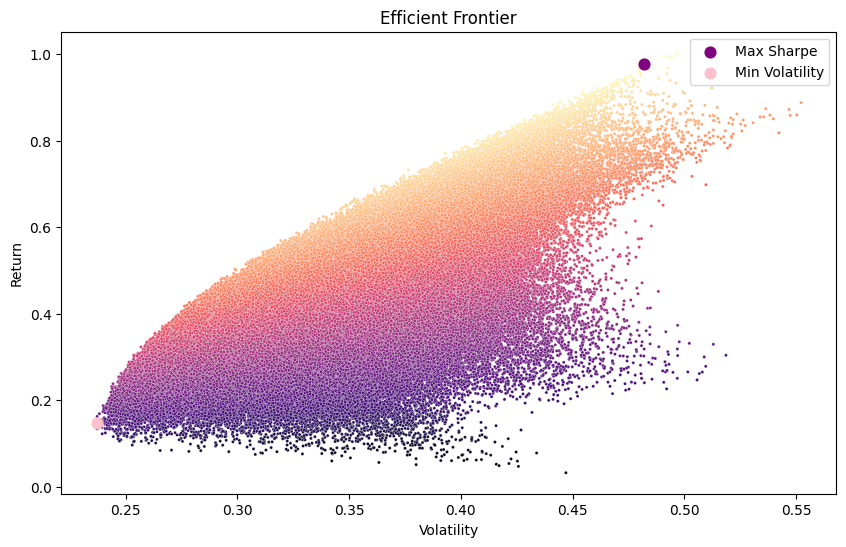

Saved Regression frontier plot to plots/regression_frontier.png
Saved Correlation matrix plot to plots/correlation_matrix.png


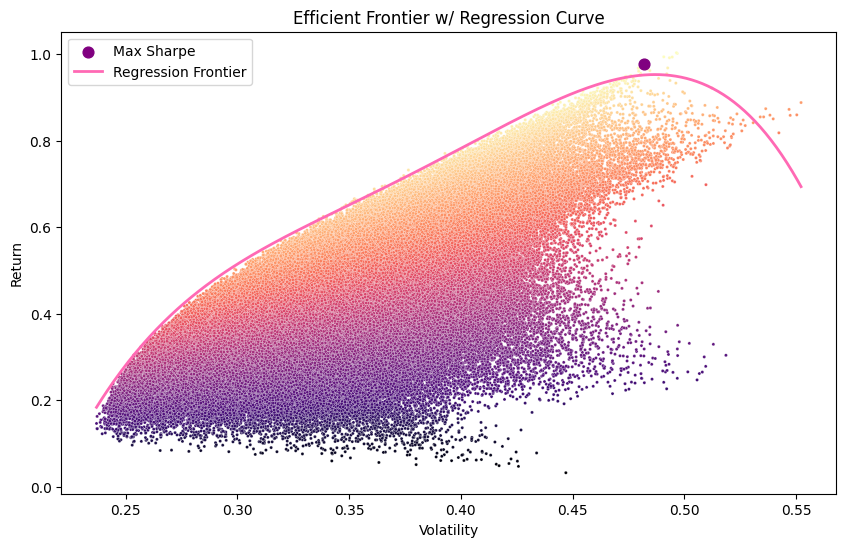

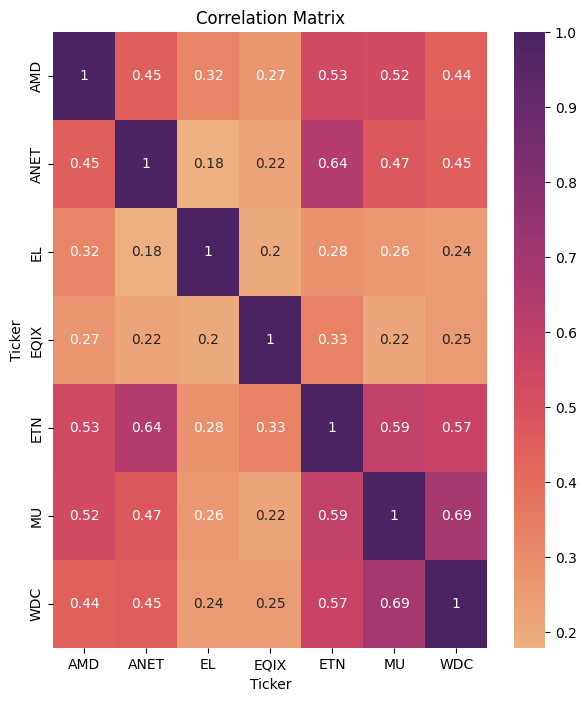

In [6]:
ef = efficientFrontier(tickers=tickers, start_date=START_DATE, end_date=END_DATE, save_dir="plots")